# AI1013 : Programming for AI

## Assignment 5

### 2. Wordle: A Game in Probability

#### 2.1 Dataset

Importing required libraries.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

Reading the CSV

In [2]:
wordlist = pd.read_csv("wordlist.csv", header=None)

#### 2.2 Data Exploration and Setup

Verifying if the wordlist was loaded correctly

In [3]:
print(len(wordlist))

3103


Great! Now lets compute and visualize the histogram as directed.

Starting by defining a function that calculates and plots the required histogram.

In [4]:
def histogram_visualization(wordlist, position):
    #for 0 based indexing
    index = position - 1

    #initializing empty frequency array
    frequency ={}


    #getting the frequency of the letters at the given position
    for word in wordlist[0]:
        frequency[word[index]] = frequency.get(word[index],0 ) + 1

    #we will be plotting alphabetically
    sorted_frequency = sorted(frequency.items())

    #preparing for plotting
    size = len(wordlist)
    letters = [freq[0] for freq in sorted_frequency]
    counts = [freq[1]/size for freq in sorted_frequency]
    
    
    #plotting
    plt.figure(figsize=(15,5))
    plt.bar(letters, counts)
    plt.title(f"Frequency visualization for position {position}.")
    plt.xlabel("Letters")
    plt.ylabel("Frequency")
    plt.grid(axis="y", linestyle="--")
    plt.show()
    

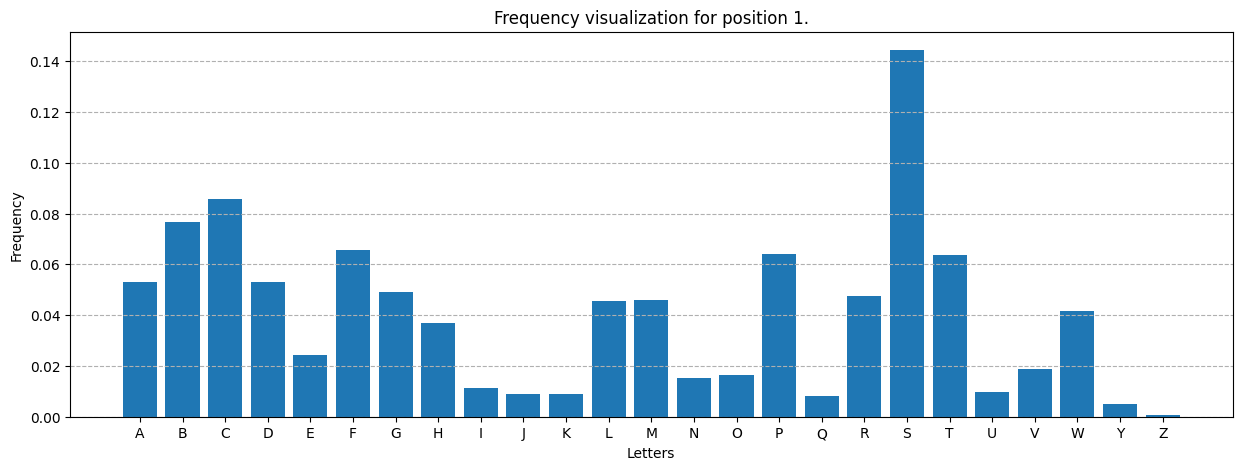

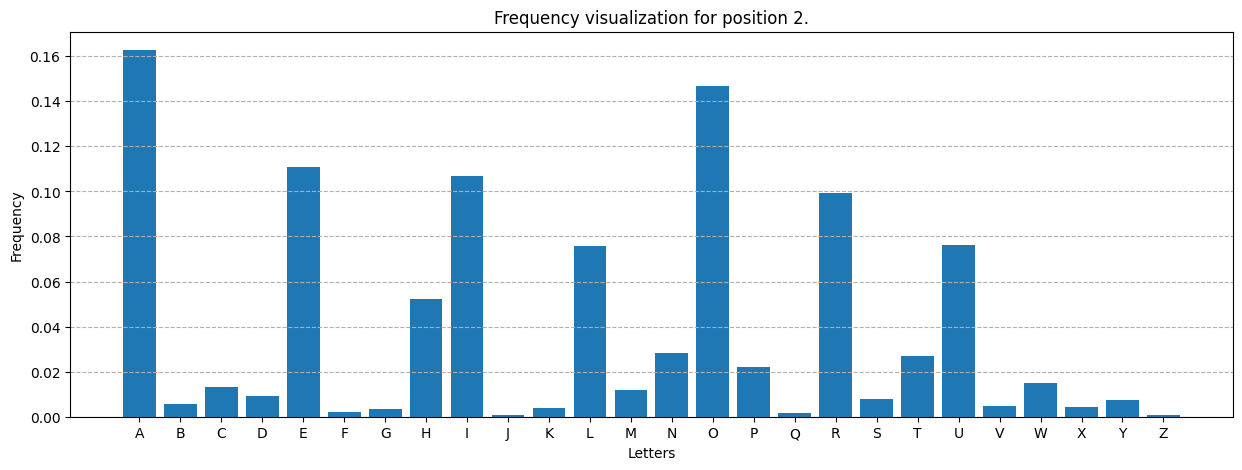

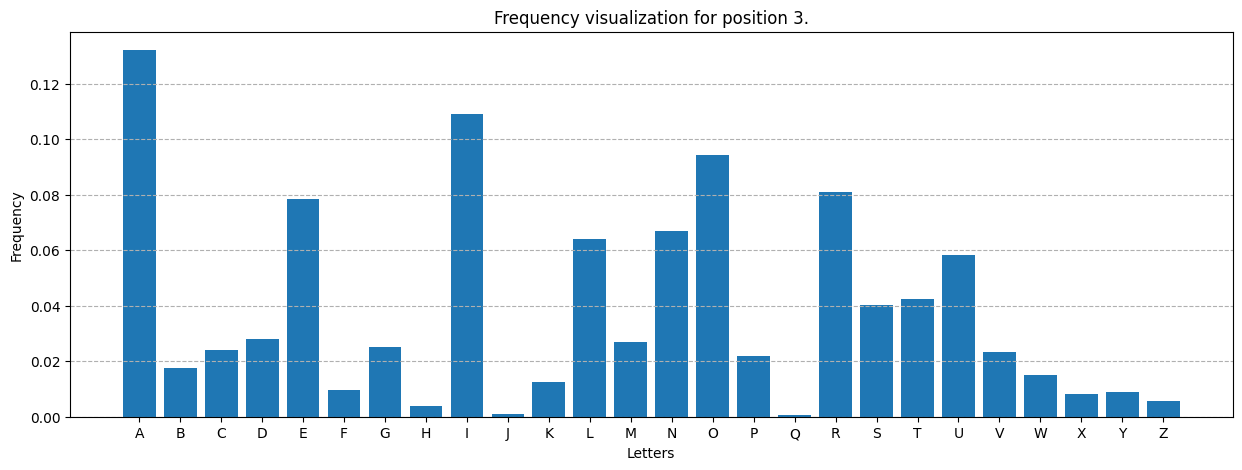

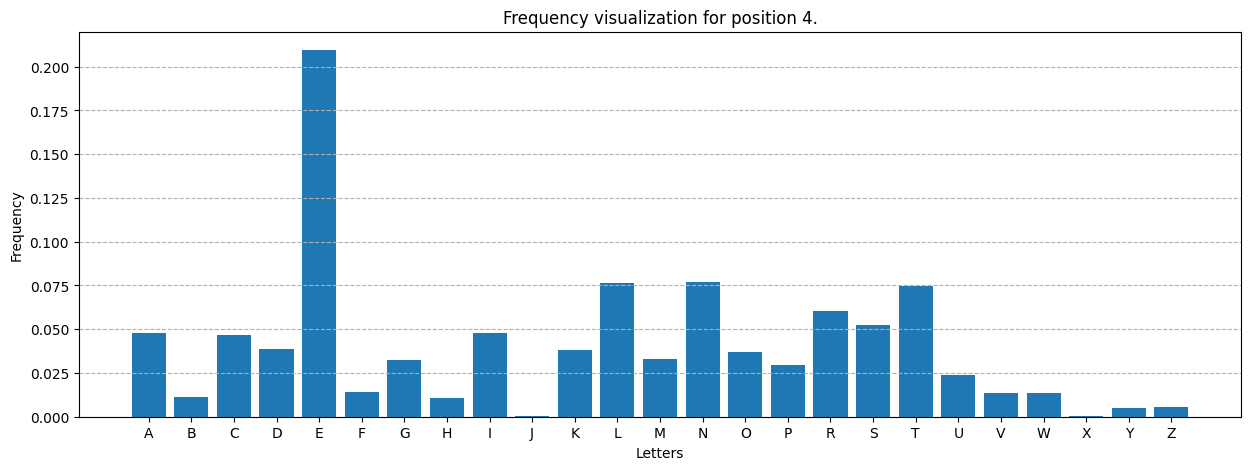

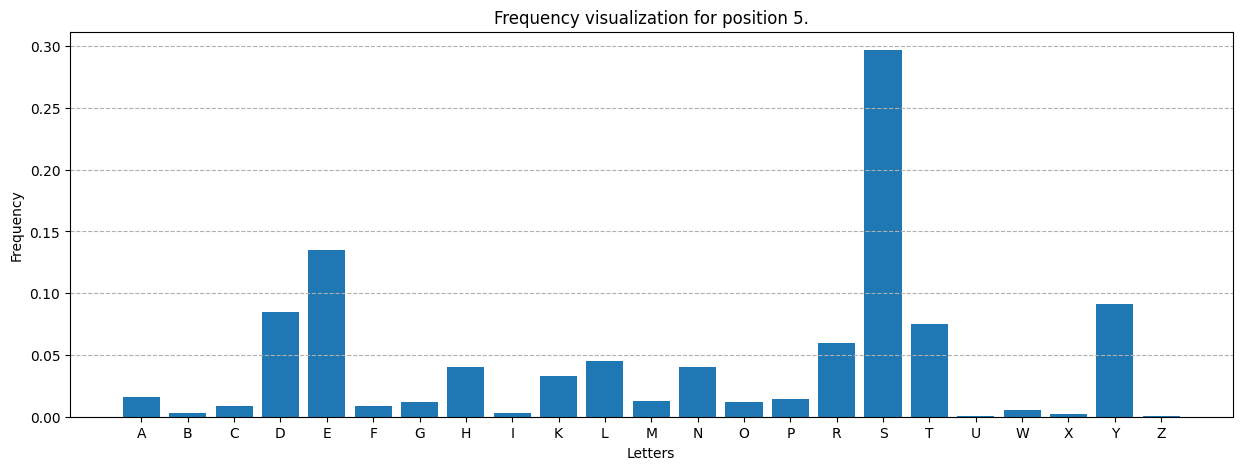

In [5]:
#plotting usin the above function
for position in range(1,6):
    histogram_visualization(wordlist, position)

The plots are here. We observe that 
1. For position 1, letter 'S' dominates, while majority of letters appearing with frequency in similar range. Some of the letters are very rare.
2. For position 2, only a few letters dominate the graph, others being rare.
3. For positon 3, again the distribution is somewhat like for position 1, but with no clear dominator this time, and more letters that occur rarely.
4. For position 4, the frequency distribution is almost same as that for position 1.
5. For position 5, only a few letters are probable to appearm with again the letter 'S' dominating the graph.

#### 2.3 Simulating Wordle Feedback

Lets define the `wordle_feedback` function as instructed

In [6]:
def wordle_feedback(guess, solution):
    #list to track yellow tiles (or gray)
    letters_incorrect_pos = []

    #count for tiles
    green_tiles = 0
    yellow_tiles = 0

    #unused indices in solution:
    unused_indices = []


    #first will check for greens if correct, increment one
    for i in range(5):
        if guess[i] == solution[i]:
            green_tiles +=1
        else:
            unused_indices.append(i)
            letters_incorrect_pos.append((i,guess[i]))
    
    #to track used solution indices
    used_solution_indices = []

    #now we'll check for the yellow tiles
    for i, letter in letters_incorrect_pos:
        for j in unused_indices:
            if j not in used_solution_indices and letter == solution[j]:
                yellow_tiles +=1
                used_solution_indices.append(j)
                break

    #remaining are gray tiles
    gray_tiles = 5-green_tiles - yellow_tiles

    return (green_tiles, yellow_tiles, gray_tiles)

Lets check if this function works fine for the given words

In [7]:
print(wordle_feedback("CRANE", "SLATE"))
#expected (2,0,3)

(2, 0, 3)


In [8]:
print(wordle_feedback("BRAIN", "BRINE"))
#expected (2,2,1)

(2, 2, 1)


Our function seems to be working fine, Lets proceed further.

#### 2.4 Probability Estimation via Averages

##### 1. Estimating the probability that a guess word results in atleast one green tile

In [9]:
np.random.seed(42) #for reproducability


#fixed guess word
guess_word = "CRANE"

def calculate_words_with_green_tile_prob(wordlist, guess_word, num_solution_words):
    #to count the 1/0
    words_with_green_tiles = 0

    #selecting words randomly
    indices = np.random.choice(len(wordlist), num_solution_words)

    for index in indices:
        green, yellow, gray = wordle_feedback(guess_word, wordlist[0][index])
        if green:
            words_with_green_tiles +=1

    return (words_with_green_tiles/num_solution_words)*100


#calculating probability
print("The probability that the word 'CRANE' results in at least one green tile = ", calculate_words_with_green_tile_prob(wordlist, guess_word, 1000), "%")


The probability that the word 'CRANE' results in at least one green tile =  37.8 %


##### 2. Estimating the probability that a guess word results in exactly two yellow tiles

In [10]:
#fixed guess word
guess_word = "CRANE"

def calculate_words_exactly_two_yellow_prob(wordlist, guess_word, num_solution_words):
    #to count the 1/0
    words_with_two_yellow = 0

    #selecting words randomly
    indices = np.random.choice(len(wordlist), num_solution_words)

    for index in indices:
        green, yellow, gray = wordle_feedback(guess_word, wordlist[0][index])
        if yellow==2:
            words_with_two_yellow +=1

    return (words_with_two_yellow/num_solution_words)*100

#calculating probability
print("The probability that the word 'CRANE' results exactly two yellow tiles = ", calculate_words_exactly_two_yellow_prob(wordlist, guess_word, 1000), "%")

The probability that the word 'CRANE' results exactly two yellow tiles =  24.4 %


#### 2.5 A Greedy Strategy and its Average Guessing Time

Making a function that returns wordle feedback along with the position of the tiles.

In [11]:
def get_wordle_feedback(guess, solution):
    #for tracking position of yellow tiles
    feedback = ['a','a','a','a','a']
    
    #list to track yellow tiles (or gray)
    letters_incorrect_pos = []

    #unused indices in solution:
    unused_indices = []


    #first will check for greens if correct, increment one
    for i in range(5):
        if guess[i] == solution[i]:
            feedback[i]='g'
        else:
            unused_indices.append(i)
            letters_incorrect_pos.append((i,guess[i]))
    
    #to track used solution indices
    used_solution_indices = []

    #now we'll check for the yellow tiles
    for i, letter in letters_incorrect_pos:
        for j in unused_indices:
            if j not in used_solution_indices and letter == solution[j]:
                feedback[i] = 'y'
                used_solution_indices.append(j)
                break

    # "g" = green
    # "y" = yellow
    # 'b' = gray

    return feedback


Lets define a function to implement the greedy strategy.

In [12]:
def check_feedback(word, solution_word, feedback):
    #not including the current solution_word as we already know this is not the answer
    #hence reducing the search space by one more word at every step
    if word == solution_word:
        return False
    
    curr_feedback = wordle_feedback( solution_word, word)
    # result = (curr_feedback[0]>=feedback[0]) or (curr_feedback[1]>=feedback[1])
    result = curr_feedback == feedback
    return result

def filter_words(wordlist, current_guess, feedback):
    filtered_words = []
    for word in wordlist:
        curr_feedback = wordle_feedback(current_guess, word)
        if curr_feedback == feedback:
            filtered_words.append(word)

    return filtered_words

def greedy_strategy(wordlist, guess_word, num_trials):
    num_steps_required = []
    incorrect= 0

    for i in range(num_trials):
        #initial filtered words are all words
        filtered_words = wordlist[0].copy()
        steps = 0

        #loop goes on till stopped by condition
        while True:
            solution_word = np.random.choice(filtered_words)
            steps +=1
            # print("steps ", steps)

            #getting feedback for the current solution
            current_feedback = wordle_feedback(solution_word, guess_word)

            if current_feedback[0] == 5:
                if(solution_word != guess_word):
                    incorrect+=1
                break

            #filtering
            mask = filtered_words.apply(check_feedback, args=(solution_word, current_feedback))
            filtered_words = filtered_words[mask]
            # filtered_words = filter_words(filtered_words, solution_word, current_feedback )
        
        num_steps_required.append(steps)

        if(not (i+1)%100):
            print(f"Completed {i+1} simulations.")

    print(incorrect)
    return np.mean(num_steps_required)


Running for "VERVE" and "CRANE" as directed

In [13]:
avg_steps_verve = greedy_strategy(wordlist, "VERVE", 1000)
avg_steps_crane = greedy_strategy(wordlist, "CRANE", 1000)

print("For 'VERVE', avg steps = ", avg_steps_verve)
print("For 'CRANE', avg steps = ", avg_steps_crane)

Completed 100 simulations.
Completed 200 simulations.
Completed 300 simulations.
Completed 400 simulations.
Completed 500 simulations.
Completed 600 simulations.
Completed 700 simulations.
Completed 800 simulations.
Completed 900 simulations.
Completed 1000 simulations.
0
Completed 100 simulations.
Completed 200 simulations.
Completed 300 simulations.
Completed 400 simulations.
Completed 500 simulations.
Completed 600 simulations.
Completed 700 simulations.
Completed 800 simulations.
Completed 900 simulations.
Completed 1000 simulations.
0
For 'VERVE', avg steps =  5.51
For 'CRANE', avg steps =  5.426


So, this greedy method using the `wordle_feedback` function defined earlier solves the wordle in around $5.5$ steps.

#### 2.6 Evaluating Different Strategies for choice of guess

Looking for a word that satisfies $S_1$'s proposal.

In [14]:
probabilities = []

for word in wordlist[0]:
    current_probability = calculate_words_with_green_tile_prob(wordlist, word, len(wordlist))
    probabilities.append((current_probability, word))

max_probability = max(probabilities, key = lambda x: x[0])[0]
possible_words = [word for prob, word in probabilities if prob == max_probability]

#randomly choosing a word

word_s1 = np.random.choice(possible_words)
print(f"According to S1, we should choose ", word_s1, "which has the probabaility of getting atleast one green tile = ", calculate_words_with_green_tile_prob(wordlist, word_s1, len(wordlist)))

According to S1, we should choose  SALES which has the probabaility of getting atleast one green tile =  62.93909120206253


Let's now look for word that satisfies $S_2$'s proposal

In [15]:
probabilities = []

for word in wordlist[0]:
    current_probability = calculate_words_exactly_two_yellow_prob(wordlist, word, len(wordlist))
    probabilities.append((current_probability, word))

max_probability = max(probabilities, key = lambda x: x[0])[0]
possible_words = [word for prob, word in probabilities if prob == max_probability]

#randomly choosing a word

word_s2 = np.random.choice(possible_words)
print(f"According to S2, we should choose ", word_s2, "which has the probabaility of getting exactly two yellow tiles = ", calculate_words_exactly_two_yellow_prob(wordlist, word_s2, len(wordlist)))

According to S2, we should choose  AISLE which has the probabaility of getting exactly two yellow tiles =  35.12729616500161
